# Elevation Analysis

DEM characterization and the role of elevation in detrending:
1. Study area topography (1 km grid)
2. Station vs. grid elevation distributions
3. Monthly normals: 2D TPS (X, Y) vs. 3D TPS (X, Y, Elev) — Haylock 2008

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from scipy.interpolate import RBFInterpolator

ROOT = Path.cwd().parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.data.dem import DEMSource
from thesis.datasets.protocols import PredictionGrid
from thesis.transforms.pipeline import TransformPipeline
from thesis.transforms.projection import ProjectionTransform
from thesis.transforms.indicator import IndicatorTransform
from thesis.transforms.detrend import DetrendTransform

In [2]:
cfg = Config()
registry = DataRegistry.from_config(cfg)
dem = DEMSource(cfg)
grid = PredictionGrid.from_config(cfg, dem=dem)

print(f"Grid shape: {grid.shape}, cells: {grid.n_cells():,}")
print(f"Elevation: {np.nanmin(grid.elevation_m):.0f} – {np.nanmax(grid.elevation_m):.0f} m "
      f"(mean {np.nanmean(grid.elevation_m):.0f} m)")

Grid shape: (462, 439), cells: 202,818
Elevation: -12 – 1344 m (mean 199 m)


## 1. Study Area Topography

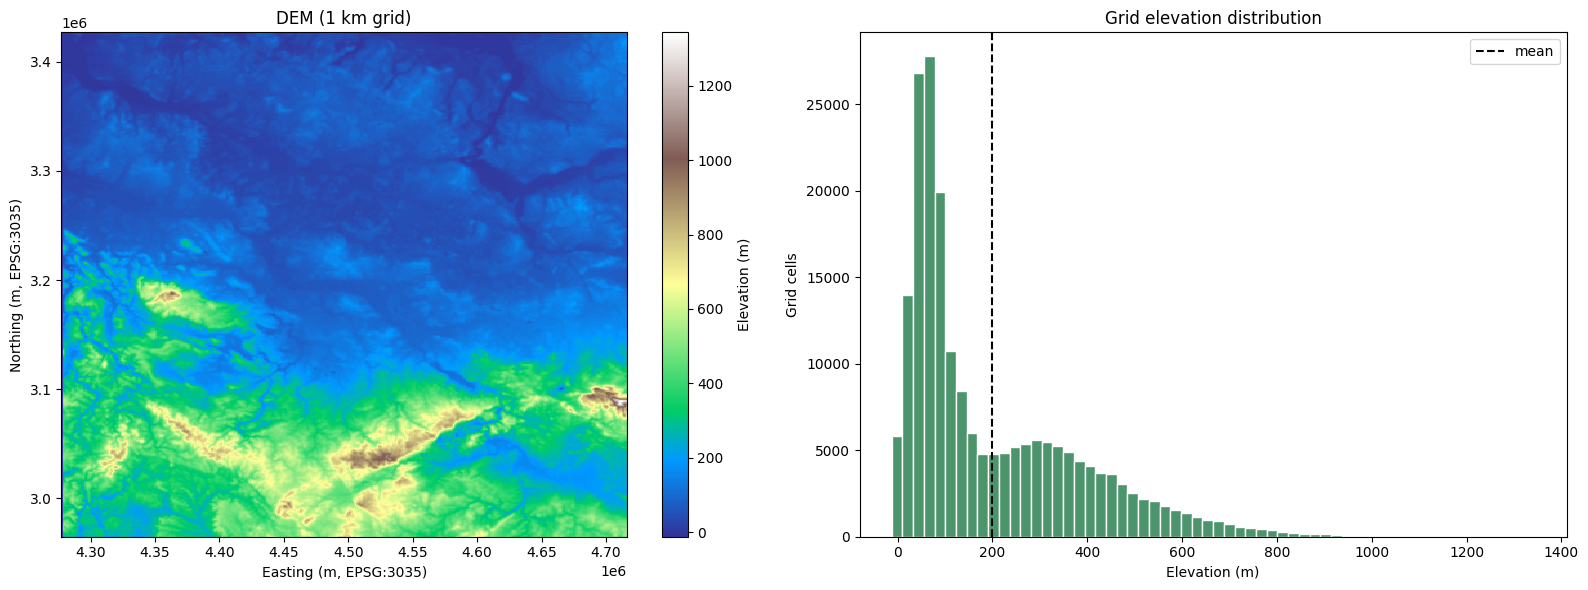

In [3]:
H, W = grid.shape
xg = grid.coords_proj[:, 0].reshape(H, W)
yg = grid.coords_proj[:, 1].reshape(H, W)
zg = grid.elevation_m.reshape(H, W)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].pcolormesh(xg, yg, zg, shading="auto", cmap="terrain")
axes[0].set_title("DEM (1 km grid)")
axes[0].set_xlabel("Easting (m, EPSG:3035)")
axes[0].set_ylabel("Northing (m, EPSG:3035)")
plt.colorbar(im, ax=axes[0], label="Elevation (m)")

axes[1].hist(grid.elevation_m, bins=60, color="#4C956C", edgecolor="white")
axes[1].set_title("Grid elevation distribution")
axes[1].set_xlabel("Elevation (m)")
axes[1].set_ylabel("Grid cells")
axes[1].axvline(np.nanmean(grid.elevation_m), color="k", ls="--", label="mean")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Station vs. Grid Elevation

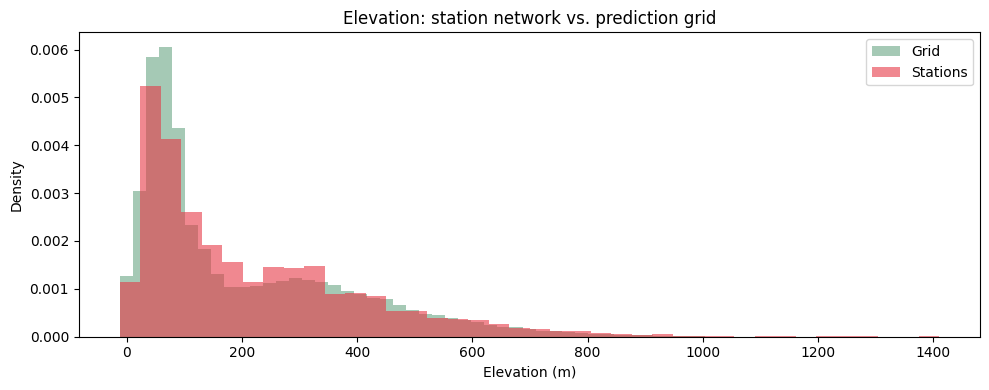

Stations: n=4986, elev -12–1410 m (mean 214 m)
Grid:     n=202,818, elev -12–1344 m (mean 199 m)


In [4]:
stations = registry.stations.load_stations()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(grid.elevation_m, bins=60, density=True, alpha=0.5, color="#4C956C", label="Grid")
ax.hist(stations["elevation_m"].dropna(), bins=40, density=True, alpha=0.6, color="#e63946", label="Stations")
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Density")
ax.set_title("Elevation: station network vs. prediction grid")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Stations: n={len(stations)}, "
      f"elev {stations['elevation_m'].min():.0f}–{stations['elevation_m'].max():.0f} m "
      f"(mean {stations['elevation_m'].mean():.0f} m)")
print(f"Grid:     n={grid.n_cells():,}, "
      f"elev {np.nanmin(grid.elevation_m):.0f}–{np.nanmax(grid.elevation_m):.0f} m "
      f"(mean {np.nanmean(grid.elevation_m):.0f} m)")